# Problem Statement

To develop a predictive model that can estimate the Item_Outlet_Sales based on item characteristics (such as type, weight, price, and fat content) and
outlet attributes (like size, type, and location). Accurate sales predictions will help the company optimize inventory, marketing, and logistics 
strategies.

# Import libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV  # Hyperparameter tuning

from sklearn.preprocessing import MinMaxScaler, StandardScaler  #Feature Scaling

from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# Read dataset

In [2]:
data = pd.read_csv('KNN_reg_outlet_sales.csv')
data

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


# Basic checks

In [3]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
data.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


i)there are total 11 features and Item_Outlet_Sales as a target column
ii)there are null values in Item_Weight, Outlet_Size 

In [6]:
data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [7]:
data.describe(include='O')

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,8523,8523,8523,8523,6113,8523,8523
unique,1559,5,16,10,3,3,4
top,FDW13,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,10,5089,1232,935,2793,3350,5577


# EDA

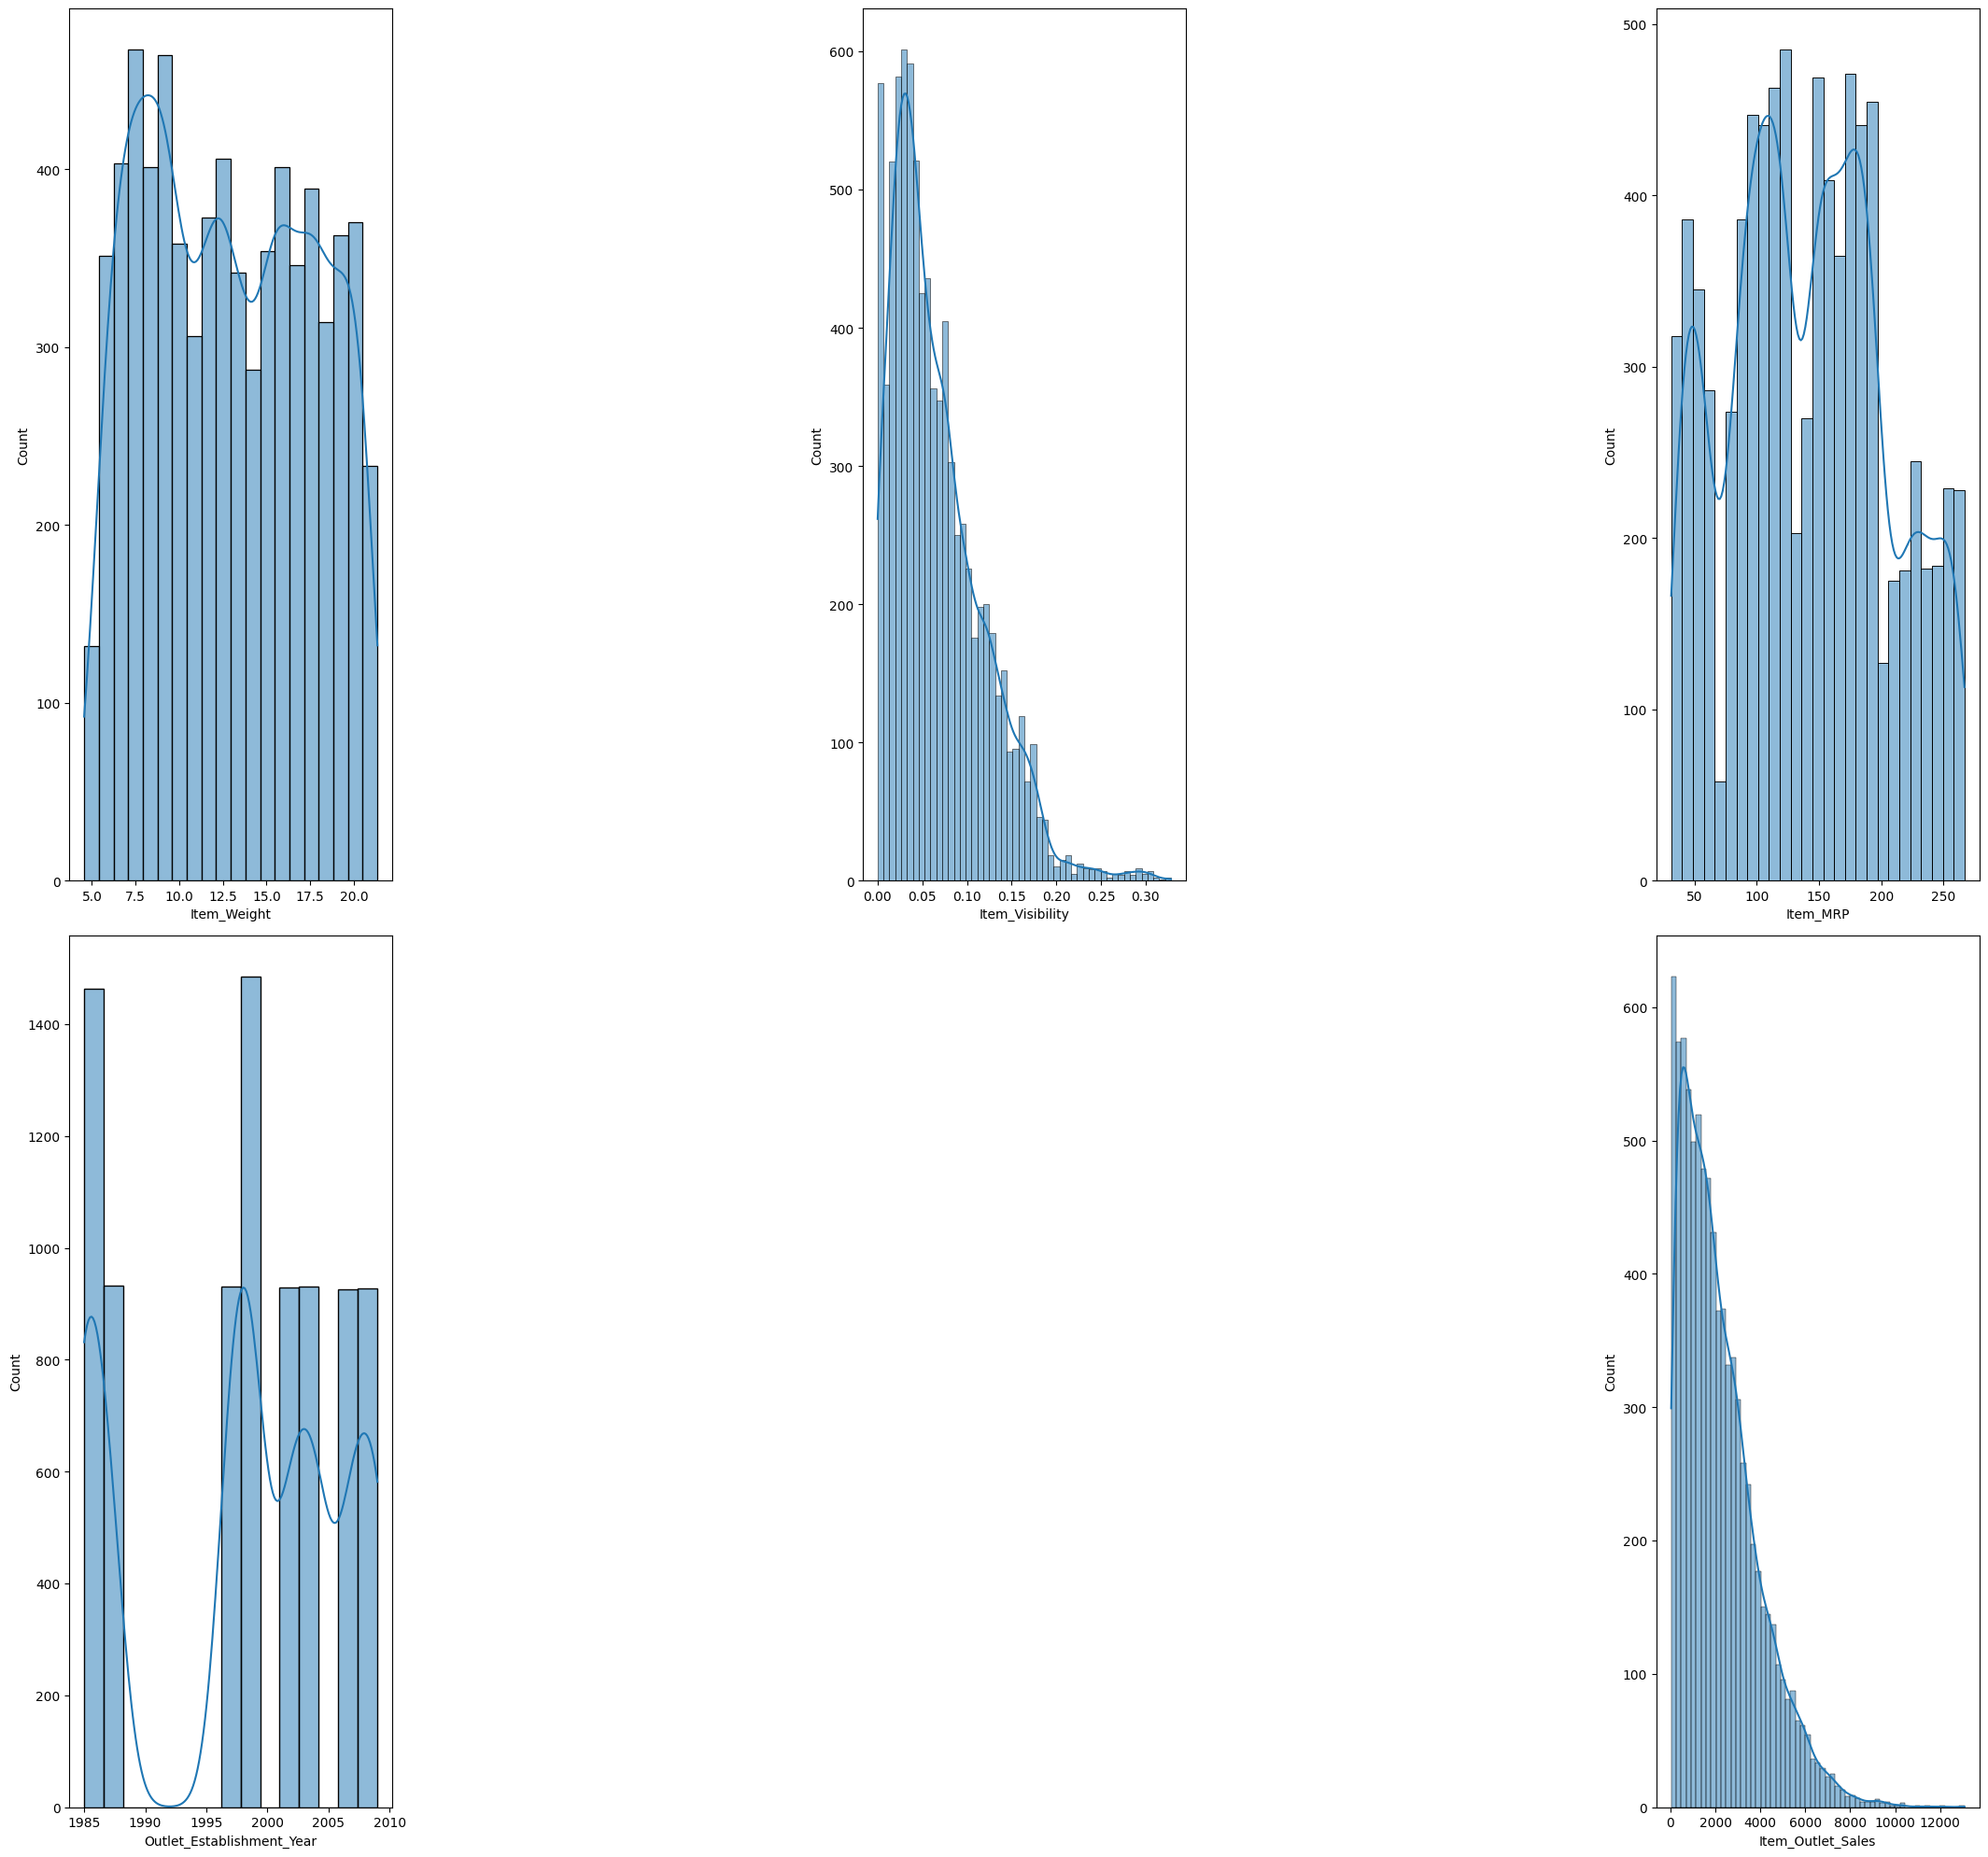

In [8]:
plotn=1
plt.figure(figsize=(25,20),facecolor='white')
for i in data.columns:
    if plotn<=12 and data[i].dtype!='object':
        ax=plt.subplot(2,6,plotn)
        sns.histplot(x=data[i],data=data,kde=True)
    plotn+=1
plt.tight_layout()
plt.show()

i)Item_Visibility and Item_Outlet_Sales are right skewed 
ii)Item_MRP appers multimodal (several peaks) means it has 3-4 major pricing clusters

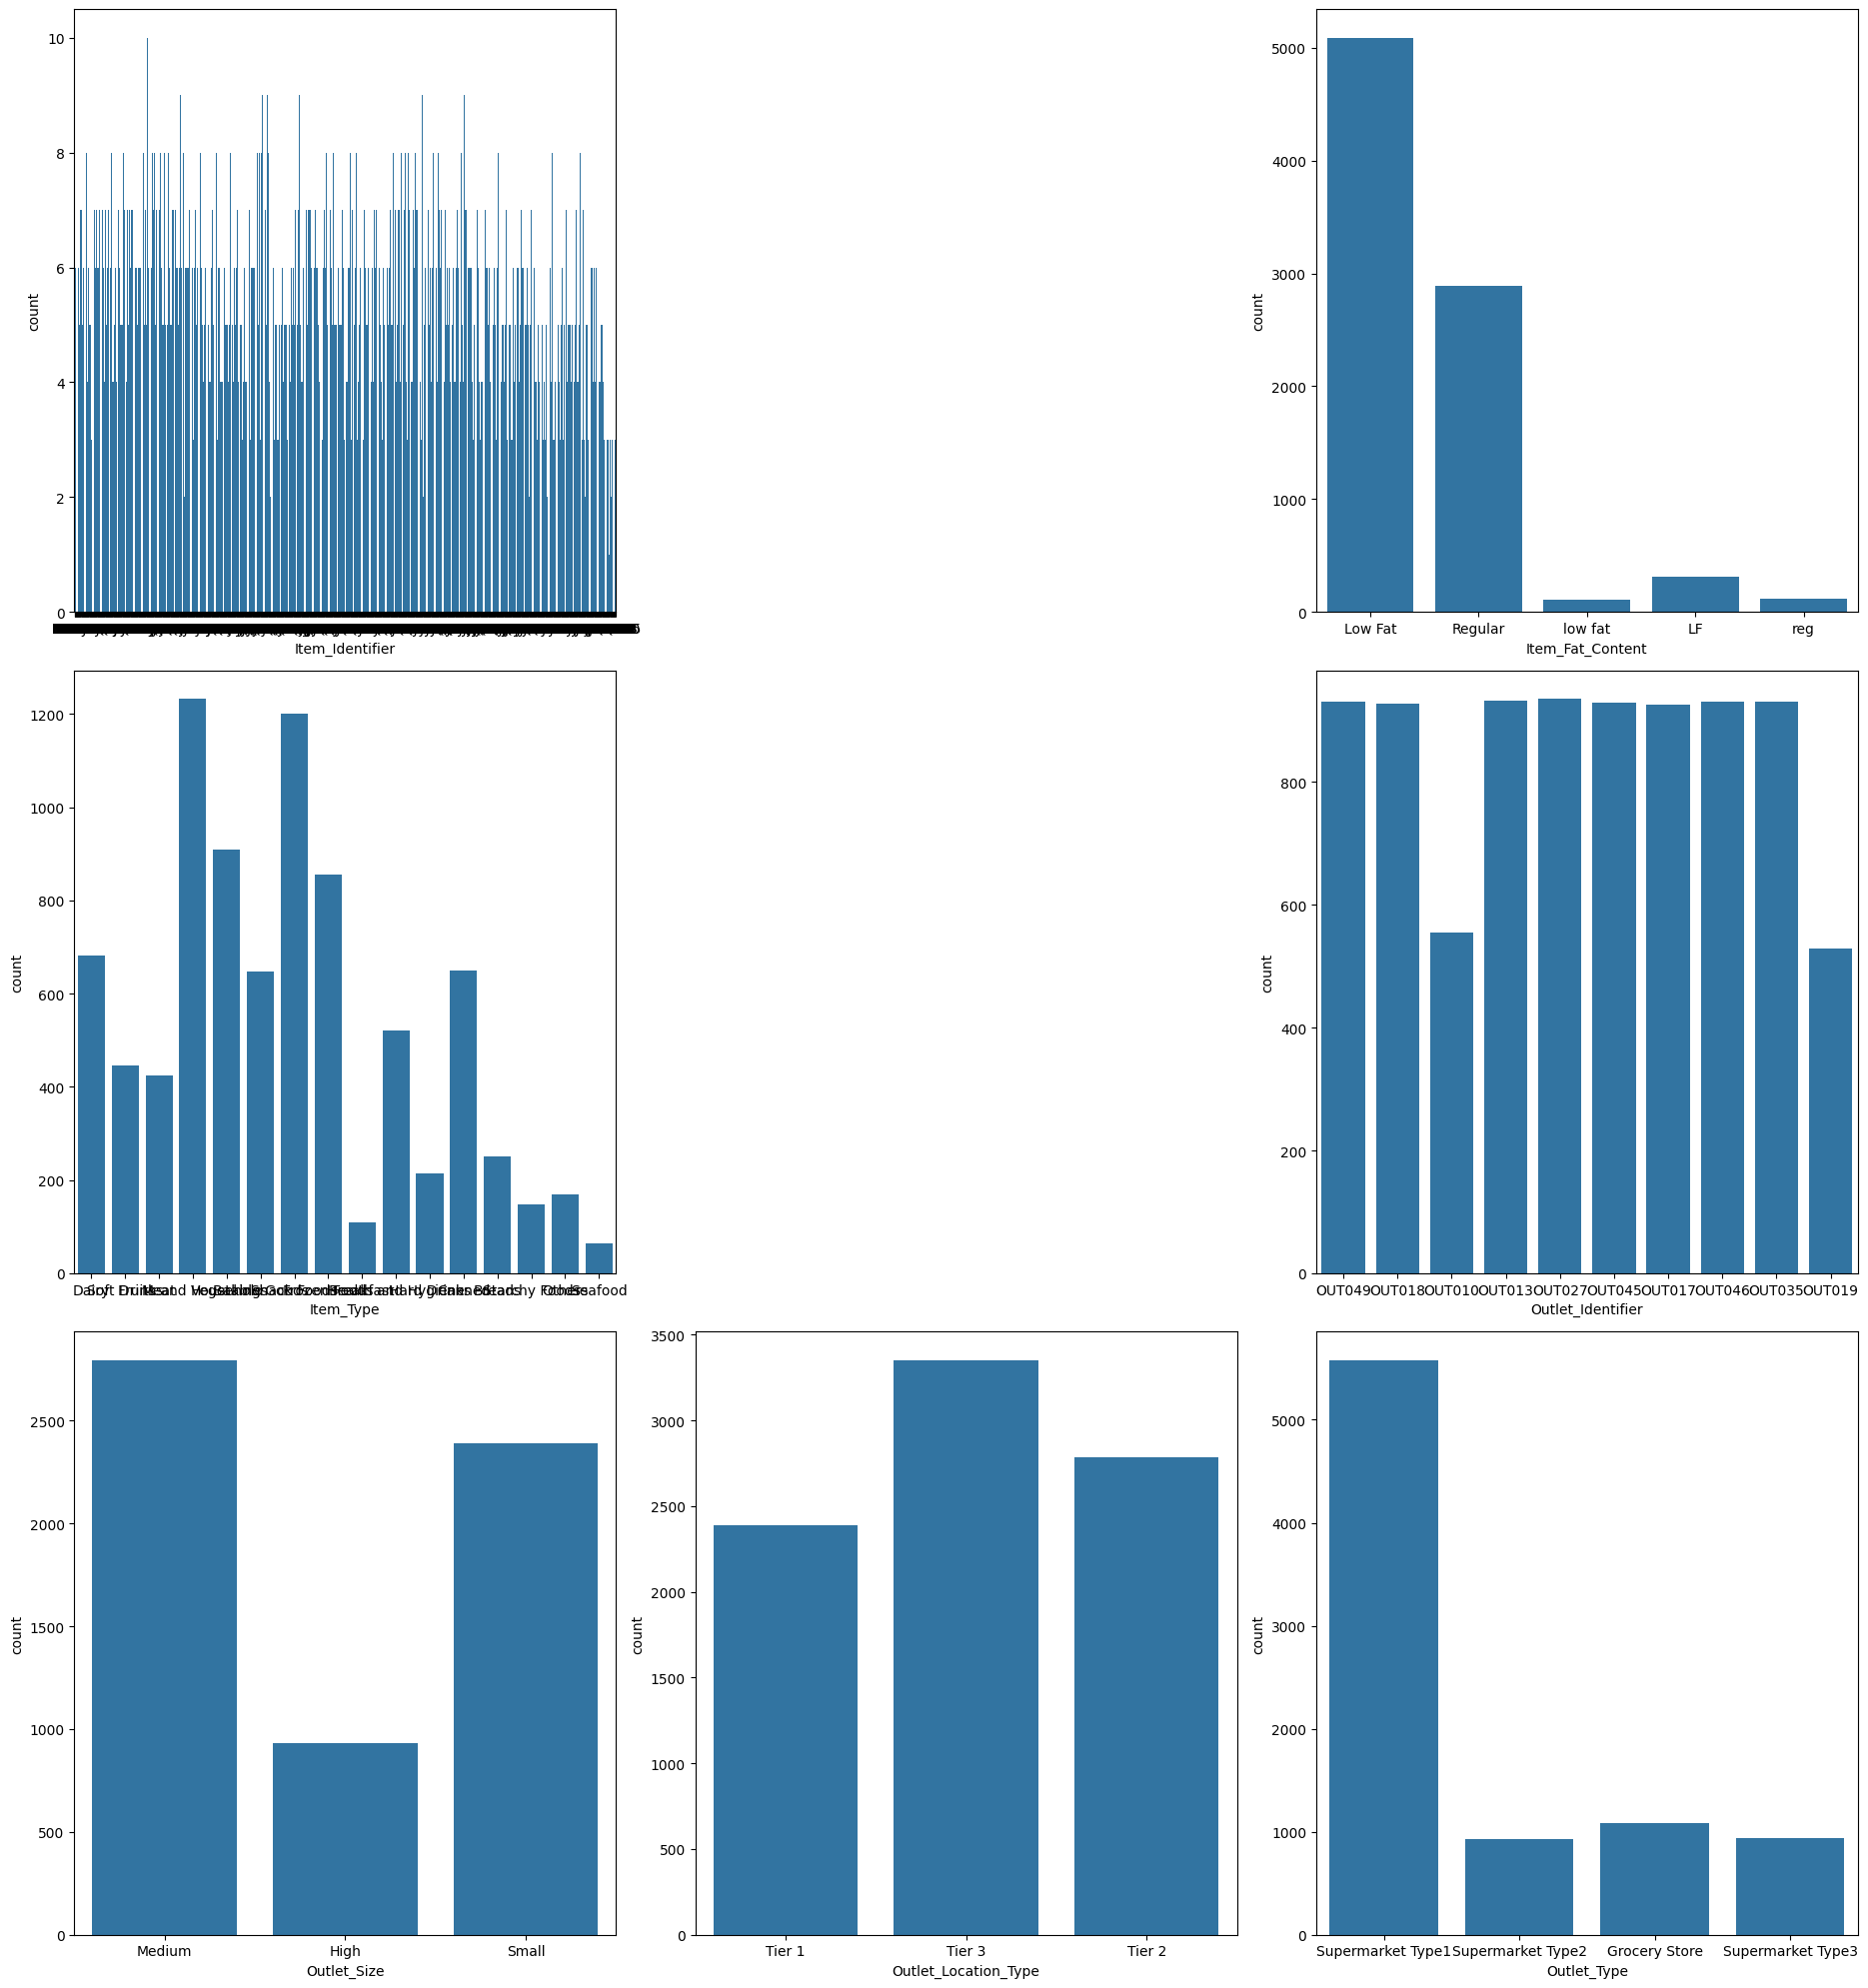

In [9]:
plotn=1
plt.figure(figsize=(25,20),facecolor='white')
for i in data.columns:
    if plotn<=12 and data[i].dtype=='object':
        ax=plt.subplot(3,4,plotn)
        sns.countplot(x=data[i],data=data)
    plotn+=1
plt.tight_layout()
plt.show()

i)Item_Fat_Content have inconsistent labels: Low Fat, low fat, and LF all represent the same category and also reg and Regular are same
ii)Medium and Small outlets dominate the dataset.High-size outlets are rare.
iii)Tier 3 locations are most common, followed by Tier 2 and Tier 1.
iv)Supermarket Type1 is the dominant type by far.Supermarket Type2, Supermarket Type3, and Grocery Store are much less frequent.

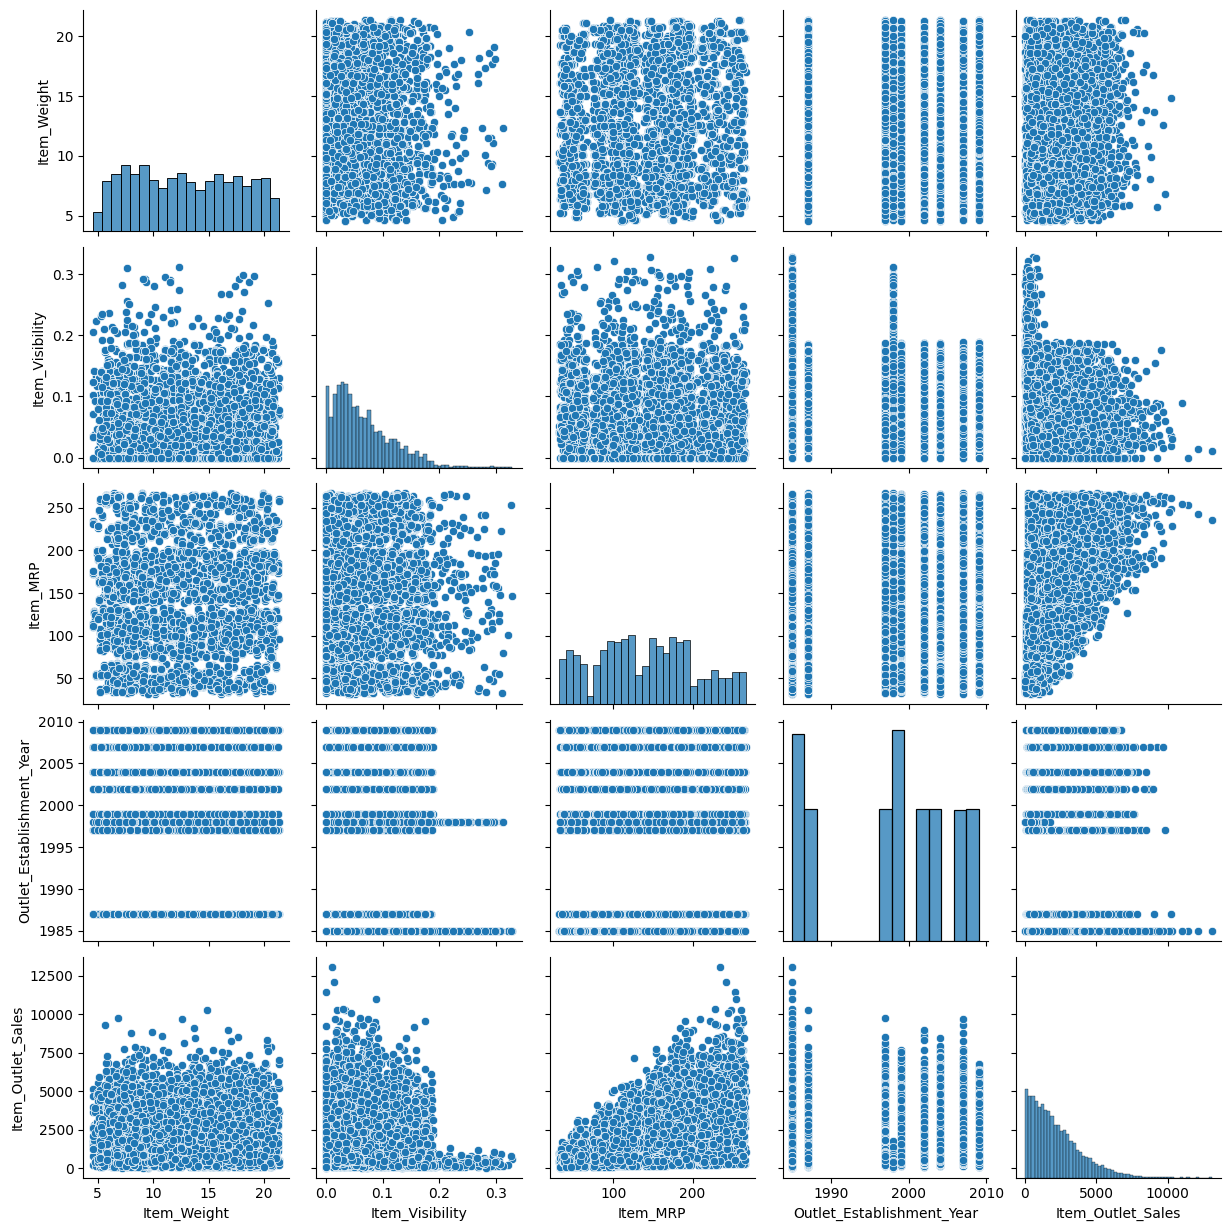

In [10]:
sns.pairplot(data)

# Data Preprocessing

In [11]:
data.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

#### 1. item weight

In [12]:
#replacing null values with median 

In [13]:
data['Item_Weight'].median()

12.6

In [14]:
data['Item_Weight'].fillna(data['Item_Weight'].median(), inplace=True)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


#### 2. Item_Fat_Content

In [16]:
#Encoding similar categories such as Low Fat,LF,low fat=0 and Regular,reg=1

In [17]:
data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [18]:
data['Item_Fat_Content'].replace({'Low Fat':0, 'Regular':1, 'LF':0, 'reg':1, 'low fat':0}, inplace=True)

In [19]:
data['Item_Fat_Content'].value_counts()

Item_Fat_Content
0    5517
1    3006
Name: count, dtype: int64

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   int64  
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 799.2+ KB


#### Item_Type

In [21]:
#encoding Item_type using pandas get_dumies() i.e one-hot encoding

In [22]:
len(data['Item_Type'].unique())

16

In [23]:
data['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [24]:
data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,0,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,1,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,0,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,1,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,0,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [25]:
Item_Type_data = pd.get_dummies(data['Item_Type'], prefix='Item_Type', drop_first= True)
Item_Type_data

,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
8519,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8520,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


#### Outlet_Identifier

In [26]:
#encoding using pandas get_dumies()

In [27]:
data['Outlet_Identifier'].value_counts()

Outlet_Identifier
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64

In [28]:
Outlet_Identifier_data = pd.get_dummies(data['Outlet_Identifier'], prefix='Outlet_Identifier')

In [29]:
Outlet_Identifier_data

,Outlet_Identifier_OUT010,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049
0,False,False,False,False,False,False,False,False,False,True
1,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True
3,True,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8518,False,True,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,False,True,False,False
8520,False,False,False,False,False,False,True,False,False,False
8521,False,False,False,True,False,False,False,False,False,False


#### Outlet_Size

In [30]:
#Encoding manually size of outlets

In [31]:
data['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [32]:
data['Outlet_Size'].replace({'Small':0,"Medium":1, "High":2}, inplace=True)

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   int64  
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   float64
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 799.2+ KB


In [34]:
data['Outlet_Size'].value_counts()

Outlet_Size
1.0    2793
0.0    2388
2.0     932
Name: count, dtype: int64

In [35]:
#handling null values with mode

In [36]:
data['Outlet_Size'].mode()

0    1.0
Name: Outlet_Size, dtype: float64

In [37]:
data['Outlet_Size'].fillna(1, inplace=True)

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   int64  
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   float64
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 799.2+ KB


#### Outlet_Location_Type

In [39]:
#Encoding manually outlet locations 

In [40]:
data['Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

In [41]:
data['Outlet_Location_Type'].replace({'Tier 1':0, 'Tier 2':1, 'Tier 3':2}, inplace=True)

#### Outlet_Type

In [42]:
#Encoding using pandas get_dumies()

In [43]:
data['Outlet_Type'].value_counts()

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

In [44]:
Outlet_Type_data = pd.get_dummies(data['Outlet_Type'], prefix='Outlet_Type', 
                                drop_first=True)

In [45]:
Outlet_Type_data

,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,True,False,False
1,False,True,False
2,True,False,False
3,False,False,False
4,True,False,False
...,...,...,...
8518,True,False,False
8519,True,False,False
8520,True,False,False
8521,False,True,False


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   int64  
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   float64
 9   Outlet_Location_Type       8523 non-null   int64  
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(5), int64(3), object(4)
memory usage: 799.2+ KB


In [47]:
#droping columns on which onehot encoding is performed

In [48]:
data.drop(['Item_Identifier','Item_Type','Outlet_Identifier', 'Outlet_Type'], axis=1, inplace=True)

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Fat_Content           8523 non-null   int64  
 2   Item_Visibility            8523 non-null   float64
 3   Item_MRP                   8523 non-null   float64
 4   Outlet_Establishment_Year  8523 non-null   int64  
 5   Outlet_Size                8523 non-null   float64
 6   Outlet_Location_Type       8523 non-null   int64  
 7   Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 532.8 KB


In [50]:
#joining dataset with encoded columns

In [51]:
data_list = [data, Item_Type_data ,Outlet_Identifier_data, Outlet_Type_data]
data = pd.concat(data_list, axis=1)
data

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Item_Type_Breads,Item_Type_Breakfast,...,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.300,0,0.016047,249.8092,1999,1.0,0,3735.1380,False,False,...,False,False,False,False,False,False,True,True,False,False
1,5.920,1,0.019278,48.2692,2009,1.0,2,443.4228,False,False,...,True,False,False,False,False,False,False,False,True,False
2,17.500,0,0.016760,141.6180,1999,1.0,0,2097.2700,False,False,...,False,False,False,False,False,False,True,True,False,False
3,19.200,1,0.000000,182.0950,1998,1.0,2,732.3800,False,False,...,False,False,False,False,False,False,False,False,False,False
4,8.930,0,0.000000,53.8614,1987,2.0,2,994.7052,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0,0.056783,214.5218,1987,2.0,2,2778.3834,False,False,...,False,False,False,False,False,False,False,True,False,False
8519,8.380,1,0.046982,108.1570,2002,1.0,1,549.2850,False,False,...,False,False,False,False,True,False,False,True,False,False
8520,10.600,0,0.035186,85.1224,2004,0.0,1,1193.1136,False,False,...,False,False,False,True,False,False,False,True,False,False
8521,7.210,1,0.145221,103.1332,2009,1.0,2,1845.5976,False,False,...,True,False,False,False,False,False,False,False,True,False


In [52]:
data.head().T

,0,1,2,3,4
Item_Weight,9.3,5.92,17.5,19.2,8.93
Item_Fat_Content,0,1,0,1,0
Item_Visibility,0.016047,0.019278,0.01676,0.0,0.0
Item_MRP,249.8092,48.2692,141.618,182.095,53.8614
Outlet_Establishment_Year,1999,2009,1999,1998,1987
Outlet_Size,1.0,1.0,1.0,1.0,2.0
Outlet_Location_Type,0,2,0,2,2
Item_Outlet_Sales,3735.138,443.4228,2097.27,732.38,994.7052
Item_Type_Breads,False,False,False,False,False
Item_Type_Breakfast,False,False,False,False,False


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item_Weight                      8523 non-null   float64
 1   Item_Fat_Content                 8523 non-null   int64  
 2   Item_Visibility                  8523 non-null   float64
 3   Item_MRP                         8523 non-null   float64
 4   Outlet_Establishment_Year        8523 non-null   int64  
 5   Outlet_Size                      8523 non-null   float64
 6   Outlet_Location_Type             8523 non-null   int64  
 7   Item_Outlet_Sales                8523 non-null   float64
 8   Item_Type_Breads                 8523 non-null   bool   
 9   Item_Type_Breakfast              8523 non-null   bool   
 10  Item_Type_Canned                 8523 non-null   bool   
 11  Item_Type_Dairy                  8523 non-null   bool   
 12  Item_Type_Frozen Foo

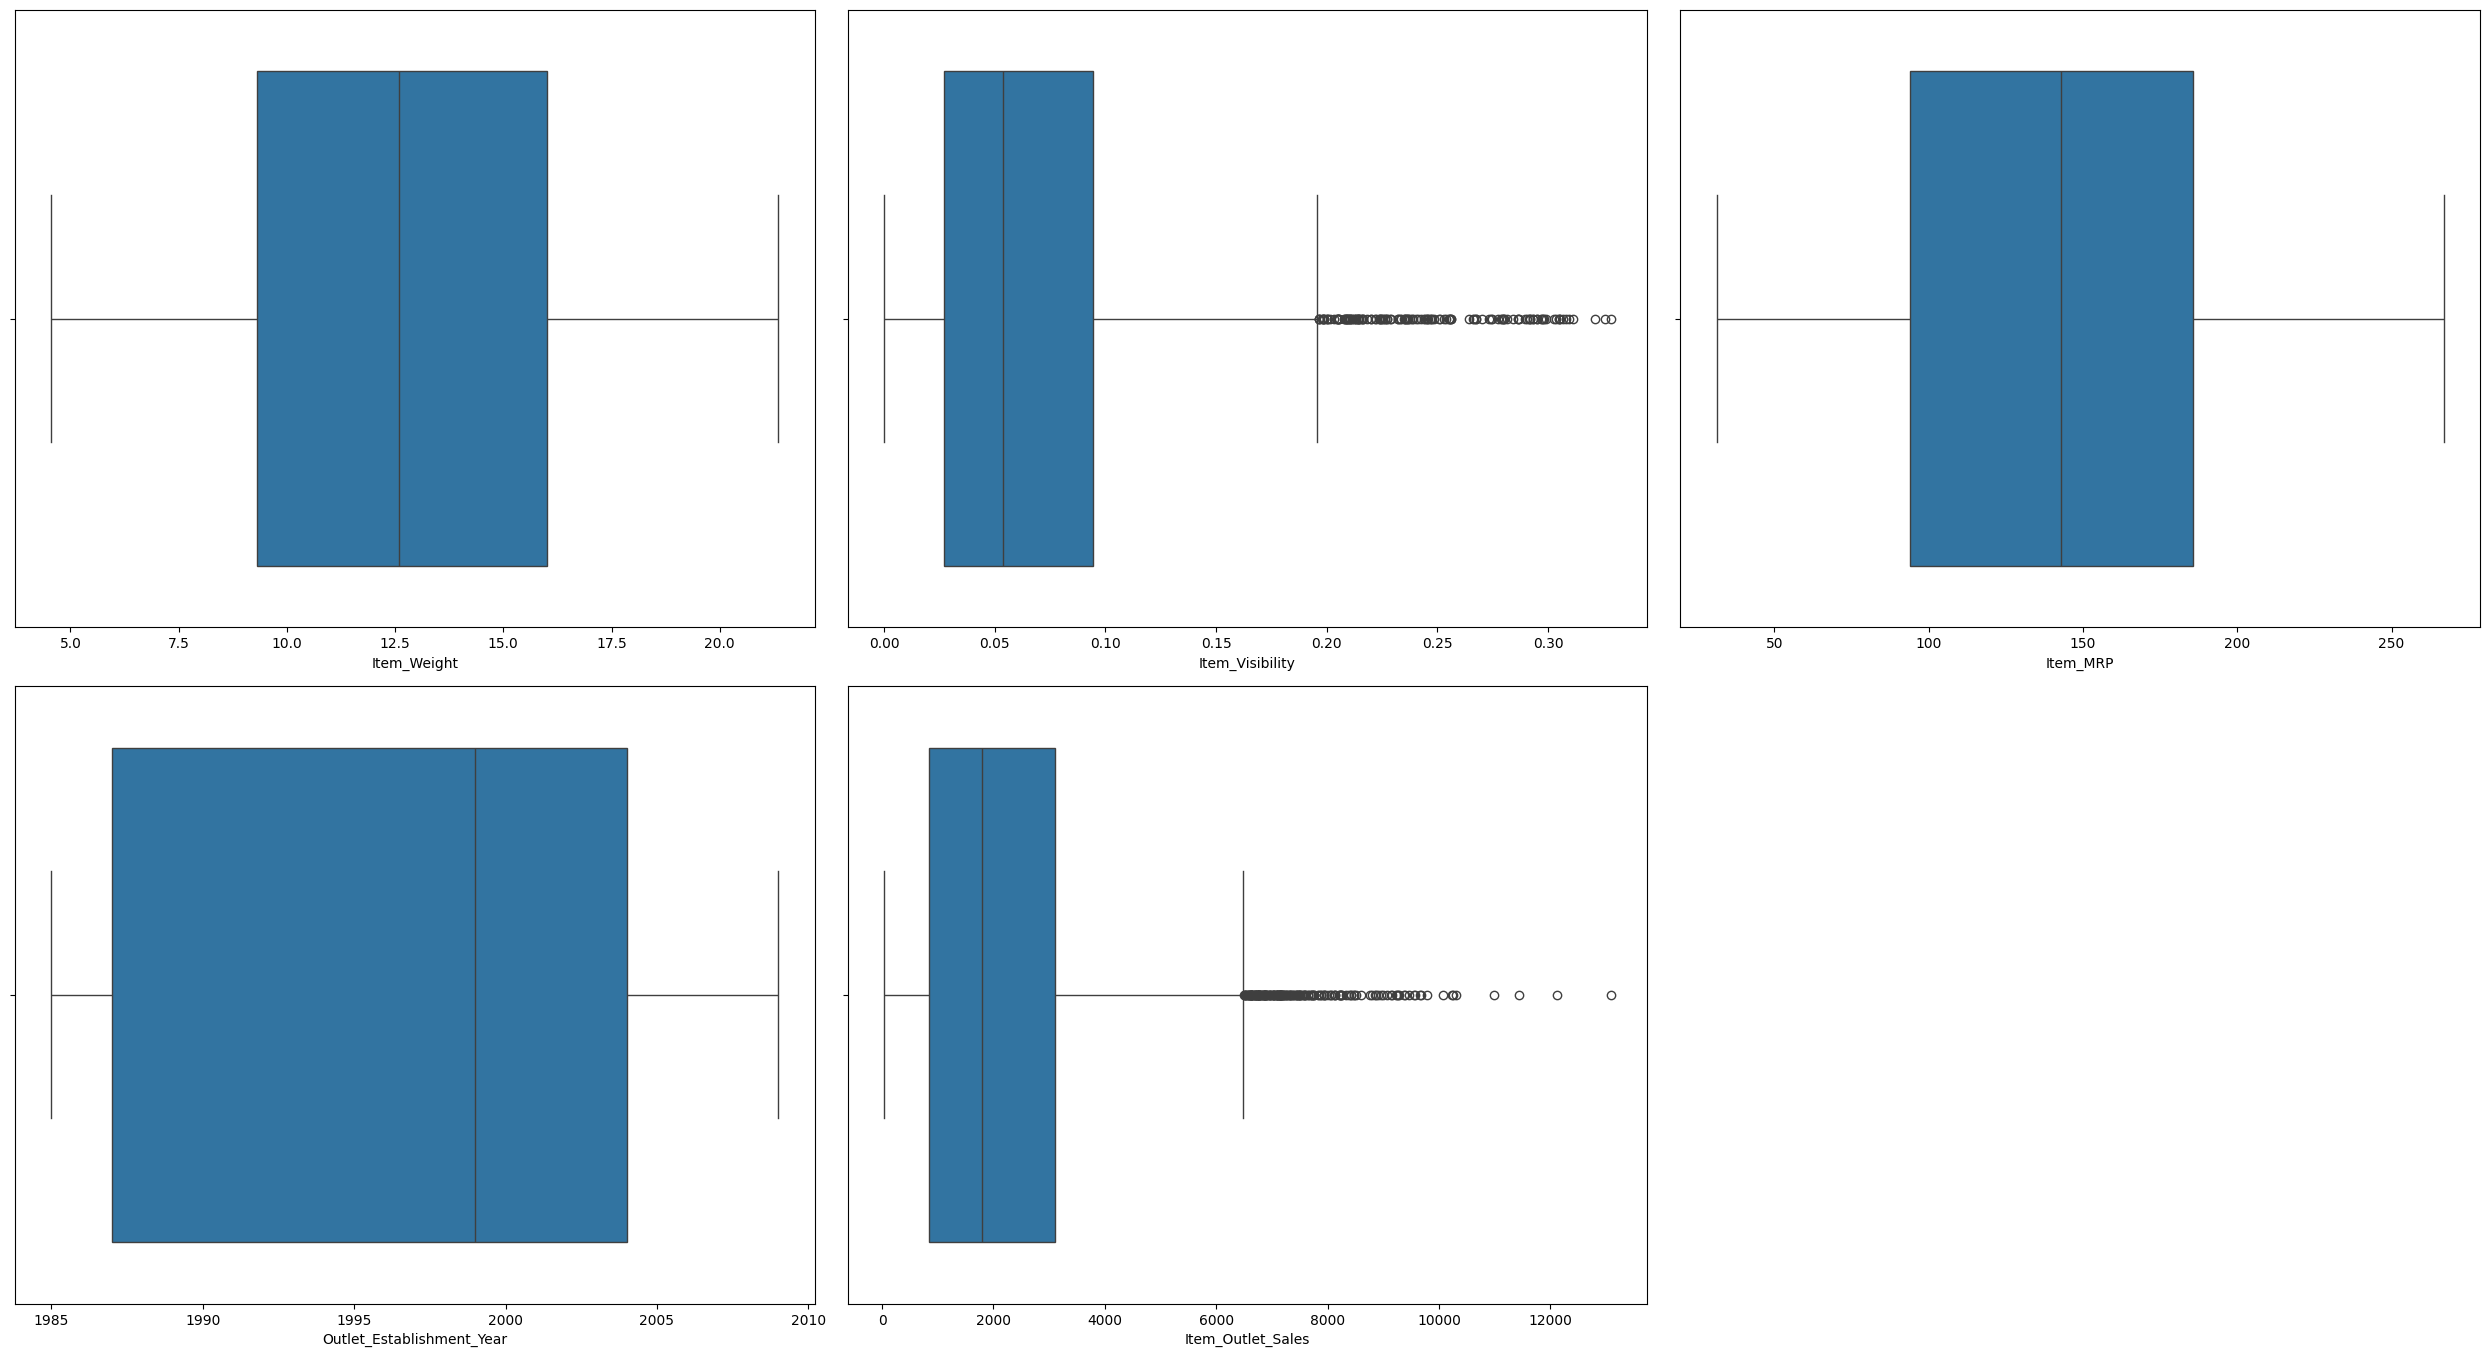

In [54]:
plotn=1
col=['Item_Weight',	'Item_Visibility',	'Item_MRP',	'Outlet_Establishment_Year',	'Item_Outlet_Sales']
plt.figure(figsize=(25,20),facecolor='white')
for i in col:
    if plotn<=5:
        ax=plt.subplot(3,3,plotn)
        sns.boxplot(x=data[i],data=data)
    plotn+=1
plt.tight_layout()
plt.show()

In [55]:
#we don't handle outliers because they seems like they are more than 5% 

In [56]:
#log transformation on Item_Outlet_Sales and Item_Visibility
data['Item_Outlet_Sales']=np.log1p(data['Item_Outlet_Sales'])


# Feature Selection

In [57]:
X = data.drop('Item_Outlet_Sales', axis=1)
y = data['Item_Outlet_Sales']

In [58]:
data

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Item_Outlet_Sales,Item_Type_Breads,Item_Type_Breakfast,...,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.300,0,0.016047,249.8092,1999,1.0,0,8.225808,False,False,...,False,False,False,False,False,False,True,True,False,False
1,5.920,1,0.019278,48.2692,2009,1.0,2,6.096776,False,False,...,True,False,False,False,False,False,False,False,True,False
2,17.500,0,0.016760,141.6180,1999,1.0,0,7.648868,False,False,...,False,False,False,False,False,False,True,True,False,False
3,19.200,1,0.000000,182.0950,1998,1.0,2,6.597664,False,False,...,False,False,False,False,False,False,False,False,False,False
4,8.930,0,0.000000,53.8614,1987,2.0,2,6.903451,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0,0.056783,214.5218,1987,2.0,2,7.929984,False,False,...,False,False,False,False,False,False,False,True,False,False
8519,8.380,1,0.046982,108.1570,2002,1.0,1,6.310436,False,False,...,False,False,False,False,True,False,False,True,False,False
8520,10.600,0,0.035186,85.1224,2004,0.0,1,7.085159,False,False,...,False,False,False,True,False,False,False,True,False,False
8521,7.210,1,0.145221,103.1332,2009,1.0,2,7.521100,False,False,...,True,False,False,False,False,False,False,False,True,False


In [59]:
X

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,...,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.300,0,0.016047,249.8092,1999,1.0,0,False,False,False,...,False,False,False,False,False,False,True,True,False,False
1,5.920,1,0.019278,48.2692,2009,1.0,2,False,False,False,...,True,False,False,False,False,False,False,False,True,False
2,17.500,0,0.016760,141.6180,1999,1.0,0,False,False,False,...,False,False,False,False,False,False,True,True,False,False
3,19.200,1,0.000000,182.0950,1998,1.0,2,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,8.930,0,0.000000,53.8614,1987,2.0,2,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0,0.056783,214.5218,1987,2.0,2,False,False,False,...,False,False,False,False,False,False,False,True,False,False
8519,8.380,1,0.046982,108.1570,2002,1.0,1,False,False,False,...,False,False,False,False,True,False,False,True,False,False
8520,10.600,0,0.035186,85.1224,2004,0.0,1,False,False,False,...,False,False,False,True,False,False,False,True,False,False
8521,7.210,1,0.145221,103.1332,2009,1.0,2,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [60]:
y

0       8.225808
1       6.096776
2       7.648868
3       6.597664
4       6.903451
          ...   
8518    7.929984
8519    6.310436
8520    7.085159
8521    7.521100
8522    6.642056
Name: Item_Outlet_Sales, Length: 8523, dtype: float64

# Train Test Split

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)

In [62]:
X_train.shape

(6392, 35)

In [63]:
X_test

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,...,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
7503,14.300,0,0.026300,79.4302,1987,2.0,2,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2957,7.930,0,0.071136,42.7086,1997,0.0,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False
7031,14.500,1,0.041313,42.0454,1999,1.0,0,False,False,True,...,False,False,False,False,False,False,True,True,False,False
1084,12.600,1,0.044767,173.7054,1985,1.0,2,False,False,False,...,False,False,True,False,False,False,False,False,False,True
856,10.195,1,0.012456,197.5110,2004,0.0,1,False,False,False,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4753,17.600,0,0.007994,171.6422,1987,2.0,2,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4836,10.195,0,0.000000,143.1154,2007,1.0,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False
8064,8.100,0,0.128296,210.4902,2002,1.0,1,False,False,False,...,False,False,False,False,True,False,False,True,False,False
4418,6.590,0,0.026226,119.0098,1999,1.0,0,False,False,False,...,False,False,False,False,False,False,True,True,False,False


In [64]:
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

# Train Model

In [65]:
knn_reg = KNeighborsRegressor()
knn_reg.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [66]:
y_pred = knn_reg.predict(X_test_scaled)
y_pred

array([7.20647383, 6.93737286, 7.17738253, ..., 7.7641656 , 7.51306788,
       7.76904341])

In [67]:
len(y_pred)

2131

In [68]:
y_test[:5]

7503    7.463974
2957    5.880166
7031    5.936239
1084    8.662069
856     7.765540
Name: Item_Outlet_Sales, dtype: float64

In [69]:
y_pred[:5]

array([7.20647383, 6.93737286, 7.17738253, 8.46552297, 8.0679814 ])

# Evaluation

In [70]:
# Mean Squared error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error is :", mse)

Mean Squared Error is : 0.4035349882191136


In [71]:
# Root Mean Squared error
rmse = np.sqrt(mse)
print("Root Mean Squared Error is :", rmse)

Root Mean Squared Error is : 0.6352440383184352


In [72]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error is :", mae)

Mean Absolute Error is : 0.49274529811470885


In [73]:
# Accuracy score
accuracy = r2_score(y_test, y_pred)
print("Accuarcy of knn model is :", accuracy)

Accuarcy of knn model is : 0.6167076618602904


# Hyperparameter Tuning

#### Grid SearchCV

In [74]:
k = np.arange(2,15)
p = [1,2]
hyp = {'n_neighbors': k, "p":p}

In [75]:
hyp

{'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 'p': [1, 2]}

In [76]:
knn_gscv = KNeighborsRegressor()
best_knn_model = GridSearchCV(knn_gscv,hyp,cv = 5)
best_knn_model.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'p': [1, 2]})

In [77]:
best_knn_model.best_params_

{'n_neighbors': 8, 'p': 1}

In [132]:
knn_reg1 = KNeighborsRegressor(n_neighbors=8, p=1)
knn_reg1.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=8, p=1)

In [133]:
y_pred1 = knn_reg1.predict(X_test_scaled)
y_pred1

array([6.96118871, 7.03744474, 7.25017521, ..., 7.54664858, 7.48335639,
       7.60684495])

In [134]:
accuarcy  = r2_score(y_test, y_pred1)
accuarcy

0.6297665841902507

#### Randomized Search CV

In [121]:
k = np.arange(2,25)
p = [1,2]
hyp = {'n_neighbors': k, "p":p}

In [122]:
hyp

{'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24]),
 'p': [1, 2]}

In [123]:
knn_rscv = KNeighborsRegressor()
best_knn_model2 = RandomizedSearchCV(knn_rscv,hyp,cv=5)
best_knn_model2.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsRegressor(),
                   param_distributions={'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24]),
                                        'p': [1, 2]})

In [124]:
best_knn_model2.best_params_

{'p': 1, 'n_neighbors': 12}

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [126]:
knn_reg2 = KNeighborsRegressor(n_neighbors=12, p=1)
knn_reg2.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=12, p=1)

In [127]:
y_pred2 = knn_reg2.predict(X_test)
y_pred2

array([6.70483007, 6.80415939, 6.54378814, ..., 8.04224682, 7.40629439,
       7.81126098])

In [128]:
# Accuracy score
accuracy = r2_score(y_test, y_pred2)
print("Accuarcy of knn model is :", accuracy)

Accuarcy of knn model is : 0.7057960653949265
